## Kernel to load: vax_inc_general 

In [1]:
import pandas as pd
import numpy as np
import pycountry
import pickle
from docx import Document
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT
from docx.shared import Pt
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import math
import jenkspy
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import make_interp_spline
import sys,os
import numpy as npz
from matplotlib.transforms import blended_transform_factory
from matplotlib.patches import Patch

In [2]:
notebook_dir = os.path.dirname(os.getcwd())
source_data_path=os.path.join(notebook_dir, "Common Source Data")
sys.path.append(source_data_path)
from country_codes import countries

In [3]:
df=pd.read_csv('Supplementary Spreadsheet- Vaccination Coverage Estimates.csv')
df_incidence= pd.read_csv(os.path.join(notebook_dir, 'Disease Incidence/Supplementary Spreadsheet- Incidence Estimates.csv'))
df["Vaccination Coverage (%)"] = df["Vaccination Coverage (%)"].clip(upper=100)
df["Vaccination Coverage (%) Upper"] = df["Vaccination Coverage (%) Upper"].clip(upper=100)

# Duplicating 'newcastle disease (velogenic)' and assigning as 'newcastle disease' (for easy comparison)
   # between the vaccination coverage dataframe and incidence dataframe for newcastle disease if desired 
mask = df_incidence['Disease'].str.contains('castle', case=False, na=False)

dup_rows = df_incidence.loc[mask].copy()

#Changing the "Disease" column in the duplicated rows to "Newcastle disease"
dup_rows['Disease'] = 'Newcastle disease'

# Appending the duplicated rows to df_incidence
df_incidence = pd.concat([df_incidence, dup_rows], ignore_index=True)


In [4]:
df=df.merge(df_incidence.drop(columns=['Country']),on=['ISO3','Year','Animal','Disease'],how='left')

In [5]:
pop_countries_cattle = df['ISO3']

for row in df.iterrows():
    if (row[1]['Country']==row[1]['Country']):
        countries[row[1]['ISO3']]=row[1]['Country']

codes_pop_cattle = [countries.get(country, 'Unknown code:'+country) for country in pop_countries_cattle]

iso3s_pop_cattle=[]

for i in pop_countries_cattle:
    try:
        iso3s_pop_cattle+=[countries[i]]
    except:
        iso3s_pop_cattle+=[None]
        
df['Country']=iso3s_pop_cattle


print(np.unique(codes_pop_cattle)) 

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola' 'Argentina'
 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bhutan'
 'Bolivia, Plurinational State of' 'Bosnia and Herzegovina' 'Botswana'
 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi'
 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Congo, The Democratic Republic of the' 'Cook Islands'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia' "Côte d'Ivoire"
 'Denmark' 'Djibouti' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Falkland Islands (Malvinas)' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Guiana' 'French Polynesia' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Greenland' 'Grenada' 'Guadeloupe' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Hondu

In [6]:
df=df.sort_values(['Country','Animal','Disease'])

In [7]:
df_pop_cattle=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO populations','cattle_pop.csv'))
df_pop_cattle = df_pop_cattle.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last').loc[:,['Area','Value','ISO3','Year']]
df_pop_cattle=df_pop_cattle.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_cattle['Animal']=['Cattle']*df_pop_cattle.shape[0]
df_pop_cattle.rename(columns={'Value':'latest pop'},inplace=True)

df_pop_poultry=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO populations',"poultry_pop.csv"))
df_pop_poultry = df_pop_poultry.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_poultry = (
    df_pop_poultry.groupby(['ISO3', 'Year Code'], as_index=False)
    .agg({
        'Domain Code': 'first',
        'Domain': 'first',
        'Area Code (M49)': 'first',
        'Area': 'first',
        'Element Code': 'first',
        'Element': 'first',
        'Item Code (CPC)': 'first',
        'Year Code': 'first',
        'Year': 'first',
        'Unit': 'first',
        'Value': 'sum',  
        'Flag': 'first',
        'Flag Description': 'first',
        'Note': 'first',
        'ISO3':'first'
    })
)
df_pop_poultry['Item'] = 'Poultry'
df_pop_poultry=df_pop_poultry.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_poultry.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_poultry['Animal']=['Poultry']*df_pop_poultry.shape[0]
df_pop_poultry['latest pop']*=1000


df_pop_swine=pd.read_csv(os.path.join(source_data_path,'Processed data','FAO populations','swine_pop.csv'))
df_pop_swine = df_pop_swine.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_swine.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_swine.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_swine['Animal']=['Pigs']*df_pop_swine.shape[0]

In [8]:
pop_countries_cattle = df_pop_cattle['Area']
pop_countries_poultry = df_pop_poultry['Area']
pop_countries_swine = df_pop_swine['Area']

codes_pop_cattle = [countries.get(country, 'Unknown code:'+country) for country in pop_countries_cattle]

iso3s_pop_cattle=[]

for i in pop_countries_cattle:
    try:
        iso3s_pop_cattle+=[countries[i]]
    except:
        iso3s_pop_cattle+=[None]
        
df_pop_cattle['ISO3']=iso3s_pop_cattle

codes_pop_poultry = [countries.get(country, 'Unknown code:'+country) for country in pop_countries_poultry]

iso3s_pop_poultry=[]

for i in pop_countries_poultry:
    try:
        iso3s_pop_poultry+=[countries[i]]
    except:
        iso3s_pop_poultry+=[None]
        
df_pop_poultry['ISO3']=iso3s_pop_poultry

codes_pop_swine = [countries.get(country, 'Unknown code:'+country) for country in pop_countries_swine]

iso3s_pop_swine=[]

for i in pop_countries_swine:
    try:
        iso3s_pop_swine+=[countries[i]]
    except:
        iso3s_pop_swine+=[None]
        
df_pop_swine['ISO3']=iso3s_pop_swine

print(np.unique(codes_pop_cattle+codes_pop_poultry+codes_pop_swine))  # prints ['AS', 'CA', 'FR']

['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLX' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CSK' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI'
 'DMA' 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI'
 'FRA' 'FRO' 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GLP' 'GMB' 'GNB' 'GNQ'
 'GRC' 'GRD' 'GTM' 'GUF' 'GUY' 'HKG' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND'
 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ'
 'KHM' 'KIR' 'KNA' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO'
 'LTU' 'LUX' 'LVA' 'MAC' 'MAR' 'MDA' 'MDG' 'MEX' 'MKD' 'MLI' 'MLT' 'MMR'
 'MNE' 'MNG' 'MOZ' 'MRT' 'MTQ' 'MUS' 'MWI' 'MYS' 'NAM' 'NCL' 'NER' 'NGA'
 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'NRU' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL'
 'PNG' 'POL' 'PRI' 'PRK' 'PRT' 'PRY' 'PSE' 'PYF' 'QAT' 'REU' 'ROU' 'RUS'
 'RWA' 'SAU' 'SCG' 'SDN' 'SEN' 'SGP' 'SLB' 'SLE' 'S

In [9]:
df_pops=pd.concat([df_pop_cattle,df_pop_poultry,df_pop_swine]).drop(columns=['Area'])

In [10]:
df_calculations_vacc=df.merge(df_pops,how='left',on=['ISO3','Animal','Year'])

df_calculations_vacc['Number of Vaccinated Lower']=df_calculations_vacc['Vaccination Coverage (%) Lower']/100*df_calculations_vacc['latest pop']
df_calculations_vacc['Number of Vaccinated Upper']=df_calculations_vacc['Vaccination Coverage (%) Upper']/100*df_calculations_vacc['latest pop']
df_calculations_vacc['Number of Vaccinated Estimate']=df_calculations_vacc['Vaccination Coverage (%)']/100*df_calculations_vacc['latest pop']
df_calculations_vacc=df_calculations_vacc[~df_calculations_vacc.loc[:,['Number of Vaccinated Lower','Number of Vaccinated Upper','Number of Vaccinated Estimate','latest pop']].isna().all(1)]




susceptible_countries_per_disease_df=pd.read_csv(os.path.join(notebook_dir,'Common Source Data','Processed data','Multisource','domestic_disease_presence_or_absence_filter.csv'))

df_calculations_vacc=df_calculations_vacc.merge(susceptible_countries_per_disease_df,on=['ISO3','Year','Disease'], how ='left')

In [11]:
with open(os.path.join(source_data_path, 'Processed data','WAHIS data','vaccines_sorted_by_use.pickle'), 'rb') as handle:
    _,_,_,top_vaccines=pickle.load(handle)
    
animals=[i[0] for i in top_vaccines]
vaccines=[i[1] for i in top_vaccines]

In [12]:
for animal, disease in zip(animals[0:10]+animals[14:17],vaccines[0:10]+vaccines[14:17]):
    if animal=='Swine':
        animal='Pigs'
    print(animal,disease,'true, lower, upper:')
    
    if disease =='Newcastle disease virus (Inf. with)':
        disease='Newcastle disease'
    

    df_analyze=df_calculations_vacc[(df_calculations_vacc['Animal']==animal)&(df_calculations_vacc['Disease']==disease)&
                                   (df_calculations_vacc['Year']==2025)&
                                   (df_calculations_vacc['Status in livestock']=='Present')]
    

    df_analyze=df_analyze[df_analyze.loc[:,['Number of Vaccinated Lower','Number of Vaccinated Upper','Number of Vaccinated Estimate','latest pop']].notna().all(1)]
    
    coverage_lower=100*sum(df_analyze['Number of Vaccinated Lower'].values)/sum(df_analyze['latest pop'].values)
    coverage_upper=100*sum(df_analyze['Number of Vaccinated Upper'].values)/sum(df_analyze['latest pop'].values)
    coverage=100*sum(df_analyze['Number of Vaccinated Estimate'].values)/sum(df_analyze['latest pop'].values)
    
    print(round(coverage,4))
    print((round(coverage_lower,4),round(coverage_upper,4)))

Poultry Newcastle disease virus (Inf. with) true, lower, upper:
17.6202
(17.3654, 18.0433)
Poultry Infectious bursal disease (Gumboro disease) true, lower, upper:
15.0423
(14.6292, 18.6311)
Cattle Anthrax true, lower, upper:
11.5681
(10.2915, 13.3551)
Poultry Avian infectious bronchitis true, lower, upper:
16.7092
(16.4211, 19.0081)
Poultry Marek's disease (-2011) true, lower, upper:
8.8059
(7.9355, 11.9717)
Cattle Rabies virus (Inf. with) true, lower, upper:
7.9294
(6.2671, 14.0936)
Cattle Foot and mouth disease virus (Inf. with) true, lower, upper:
16.6396
(16.6285, 16.6554)
Cattle Lumpy skin disease virus (Inf. with) true, lower, upper:
33.7989
(33.433, 34.3842)
Cattle Brucella abortus (Inf. with) true, lower, upper:
7.4644
(6.7101, 8.81)
Poultry Avian infectious laryngotracheitis true, lower, upper:
9.1728
(8.4868, 13.6692)
Pigs Classical swine fever virus (Inf. with) true, lower, upper:
6.5611
(6.5576, 6.5654)
Pigs Anthrax true, lower, upper:
4.9609
(3.2808, 8.7559)
Pigs Rabies vi

In [13]:
diseases_info = [
    {"Disease": "Newcastle disease", "Animal": "Poultry"},
    {"Disease": "Infectious bursal disease (Gumboro disease)", "Animal": "Poultry"},
    {"Disease": "Avian infectious bronchitis", "Animal": "Poultry"},
    {"Disease": "Marek's disease (-2011)", "Animal": "Poultry"},
    {"Disease": "Avian infectious laryngotracheitis", "Animal": "Poultry"},
    {"Disease": "Anthrax", "Animal": "Cattle"},
    {"Disease": "Rabies virus (Inf. with)", "Animal": "Cattle"},
    {"Disease": "Foot and mouth disease virus (Inf. with)", "Animal": "Cattle"},
    {"Disease": "Brucella abortus (Inf. with)", "Animal": "Cattle"},
    {"Disease": "Lumpy skin disease virus (Inf. with)", "Animal": "Cattle"},
    {"Disease": "Classical swine fever virus (Inf. with)", "Animal": "Pigs"},
    {"Disease": "Anthrax", "Animal": "Pigs"},
    {"Disease": "Rabies virus (Inf. with)", "Animal": "Pigs"},
]

In [14]:
df_2025 = df_calculations_vacc[df_calculations_vacc["Year"] == 2025].copy()
df_2025["Unvaccinated"] = (df_2025["latest pop"] - df_2025["Number of Vaccinated Estimate"]).clip(lower=0)

In [15]:
def fmt_big(n):
    if pd.isna(n): return ""
    n = float(n)
    if n >= 1_000_000_000: return f"{n/1_000_000_000:.1f}B"
    if n >= 1_000_000:     return f"{n/1_000_000:.0f}M"
    if n >= 1_000:         return f"{n/1_000:.0f}K"
    return str(int(n))

def top10_by_unvax(df_disease):
    df = df_disease.copy()
    df["vacc_percent"] = 100 * df["Number of Vaccinated Estimate"] / df["latest pop"]
    df["vacc_percent"] = df["vacc_percent"].clip(lower=0, upper=100)
    df["gap_percent"]  = 100 - df["vacc_percent"]
    df["unvax_count"]  = df["latest pop"] - df["Number of Vaccinated Estimate"]
    df = df.sort_values("unvax_count", ascending=False).head(10)
    # ordering by size (largest at top)
    df = df.sort_values("gap_percent", ascending=False)
    return df

def build_groups(diseases_info):
    groups = {"Cattle": [], "Pigs": [], "Poultry": []}
    for d in diseases_info:
        animal = d["Animal"]
        groups.setdefault(animal, []).append(d)
    return groups
animal_groups = build_groups(diseases_info)

def top10_unvax_slice(df, animal, disease):
    d = df[(df["Animal"]==animal) & (df["Disease"]==disease)].copy()
    if d.empty: 
        return d
    d["vaccinated"]   = d["Number of Vaccinated Estimate"].clip(lower=0)
    d["total"]        = d["latest pop"].clip(lower=0)
    d["unvaccinated"] = (d["total"] - d["vaccinated"]).clip(lower=0)
    d["vacc_percent"] = (100 * d["vaccinated"] / d["total"]).replace([np.inf, -np.inf], np.nan).fillna(0).clip(0,100)
    d = d.sort_values("unvaccinated", ascending=False).head(10)
    # order small->large so largest ends up at bottom when we invert y
    d = d.sort_values(["unvaccinated","total"], ascending=[True, True])
    return d

def clean_title(name):
    t = name.replace(' (Inf. with)', '').replace(' (-2011)', '').replace(' virus','')
    return (t, True) if t == "Brucella abortus" else (t, False)

C:\Users\alecm\AppData\Local\Temp\ipykernel_30364\122235348.py:175: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([easier_format(tick, None) for tick in ticks])


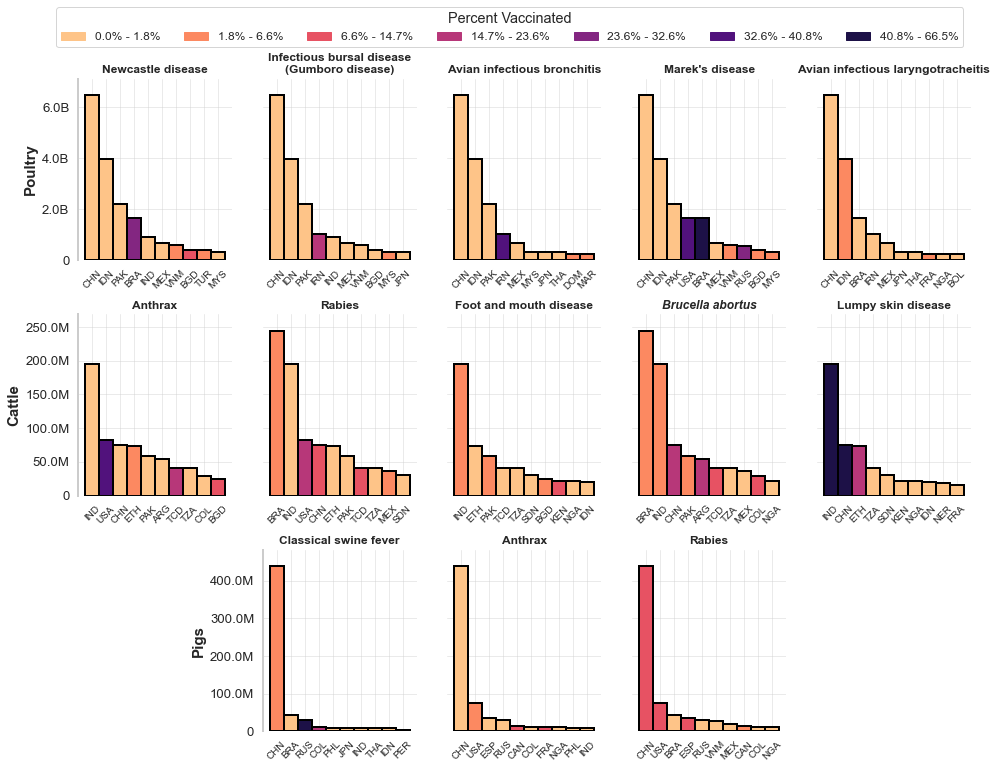

In [16]:
x_tick_distance = 1.5   # Spacing between x-ticks.
bar_width = 1.5         # Bar width.
classes = 7             # Use 7 classes for clarity.

def easier_format(num, pos):
    """Format large numbers in a more readable format."""
    if num >= 1_000_000_000:
        return f'{num / 1_000_000_000:.1f}B'
    elif num >= 1_000_000:
        return f'{num / 1_000_000:.1f}M'
    elif num >= 1_000:
        return f'{num / 1_000:.1f}K'
    return str(int(num))
df_2025 = df_calculations_vacc[df_calculations_vacc["Year"] == 2025].copy()
df_2025["Unvaccinated"] = (df_2025["latest pop"] - df_2025["Number of Vaccinated Estimate"]).clip(lower=0)

sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    'axes.linewidth': 2,
    'grid.alpha': 0.4,
    'xtick.major.size': 5,
    'ytick.major.size': 5
})

animal_groups = {"Poultry": [], "Cattle": [], "Pigs": []}
for disease in diseases_info:
    if disease["Animal"] in animal_groups:
        animal_groups[disease["Animal"]].append(disease)

cols = 5   
rows = len(animal_groups)  

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharey=False)
fig.subplots_adjust(hspace=0.3)

if rows == 1:
    axes = [axes]
else:
    axes = axes.reshape(rows, cols)

subplot_info = []   
global_percents = []
max_y_values = {}   

for row_idx, (animal, diseases) in enumerate(animal_groups.items()):
    max_y_values[animal] = 0  
    for col_idx, disease_info in enumerate(diseases):
        disease_name = disease_info["Disease"]
        

        if animal != 'Pigs':
            ax = axes[row_idx, col_idx]
            if col_idx == 0:
                ax.set_ylabel(animal, fontsize=15, fontweight='bold')
                ax.spines['left'].set_visible(True)
                ax.spines['left'].set_linewidth(2)
                ax.tick_params(axis='y', labelleft=True)
            else:
                ax.set_ylabel("")
                ax.spines['left'].set_visible(False)
                ax.tick_params(axis='y', labelleft=False)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
        else:
            col_idx_shifted = col_idx + 1  # shift right by one column.
            ax = axes[row_idx, col_idx_shifted]
            if col_idx_shifted == 1:
                ax.set_ylabel(animal, fontsize=15, fontweight='bold')
                ax.spines['left'].set_visible(True)
                ax.spines['left'].set_linewidth(2)
                ax.tick_params(axis='y', labelleft=True)
            else:
                ax.set_ylabel("")
                ax.spines['left'].set_visible(False)
                ax.tick_params(axis='y', labelleft=False)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
        if 'castle' not in disease_name:
            df_disease = df_2025[
                (df_2025["Disease"] == disease_name) & (df_2025["Animal"] == animal) 
                                                                                        &(df_2025['Source_x']!='Imputed')
            ]
        else:
            df_disease = df_2025[
                (df_2025["Disease"] == disease_name) & (df_2025["Animal"] == animal) &(df_2025['Source_x']!='Imputed')
            ]         
            
        df_disease=df_disease[(df_disease['Status in livestock']=='Present')]

    
        if df_disease.empty:
            ax.set_visible(False)
            continue

        df_disease = df_disease.copy()  # to add new columns
        df_disease["Total"] = df_disease["Number of Vaccinated Estimate"] + df_disease["Unvaccinated"]
        df_disease["Percent_Vaccinated"] = df_disease.apply(
            lambda row: (row["Number of Vaccinated Estimate"] / row["Total"] * 100) if row["Total"] > 0 else 0,
            axis=1
        )
        
        top_countries = df_disease.nlargest(10, "Unvaccinated").copy()
        if top_countries.empty:
            ax.set_visible(False)
            continue
        top_countries = top_countries.sort_values("latest pop", ascending=False).reset_index(drop=True)

        current_max = top_countries["Total"].max()
        max_y_values[animal] = max(max_y_values.get(animal, 0), current_max)
        
        x_positions = np.arange(len(top_countries)) * x_tick_distance
        
        # Accumulate percent vaccinated values.
        global_percents.extend(top_countries["Percent_Vaccinated"].tolist())
        
        if 'bursal' in disease_name.lower():
            plot_title = 'Infectious bursal disease\n(Gumboro disease)'
        else:
            plot_title = disease_name.replace(' (Inf. with)', '').replace(' (-2011)', '').replace(' virus','')

        if disease_name == "Brucella abortus (Inf. with)":
            ax.set_title("Brucella abortus", fontsize=12, fontweight="bold", fontstyle="italic")
        else:
            ax.set_title(plot_title, fontsize=12, fontweight='bold')

        ax.set_xticks(x_positions)
        ax.set_xticklabels(top_countries["ISO3"], rotation=45, fontsize=10)
        if row_idx < rows - 1:
            ax.set_xlabel("")
        
        subplot_info.append({
            "ax": ax,
            "top_countries": top_countries,
            "x_positions": x_positions,
            "animal": animal
        })

global_breaks = jenkspy.jenks_breaks(global_percents, n_classes=classes)

def get_group(value, breaks):
    """Return the group index that 'value' falls into given 'breaks'."""
    for i in range(len(breaks) - 1):
        if breaks[i] <= value <= breaks[i+1]:
            return i
    return len(breaks) - 2

colors = sns.color_palette("magma", classes)[::-1]

for info in subplot_info:
    ax = info["ax"]
    top_countries = info["top_countries"]
    x_positions = info["x_positions"]
    
    bar_colors = []
    for idx, row in top_countries.iterrows():
        pct = row["Percent_Vaccinated"]
        group = get_group(pct, global_breaks)
        bar_colors.append(colors[group])
    
    ax.bar(
        x_positions,
        top_countries["Total"],
        width=bar_width,
        color=bar_colors,
        edgecolor="black",
        linewidth=2
    )
    
    ax.ticklabel_format(style='plain', useOffset=False, axis='y')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(easier_format))
    ax.set_yscale("linear")
    ticks = ax.get_yticks()
    ax.set_yticklabels([easier_format(tick, None) for tick in ticks])

for info in subplot_info:
    animal = info["animal"]
    ax = info["ax"]
    ax.set_ylim(0, max_y_values[animal] * 1.1)

legend_handles = []
for i in range(classes):
    label = f"{global_breaks[i]:.1f}% - {global_breaks[i+1]:.1f}%"
    patch = mpatches.Patch(color=colors[i], label=label)
    legend_handles.append(patch)
    
for row_idx in range(rows):
    if row_idx == 2:  
        axes[2, 0].set_visible(False)
        axes[2, 4].set_visible(False)
    
fig.legend(handles=legend_handles, title="Percent Vaccinated", ncol=classes,
           loc="upper center", bbox_to_anchor=(0.5, 0.97), fontsize=12)
fig.savefig("vaccination_potential_color_gradient.svg", format="svg", dpi=600, bbox_inches="tight")
fig.savefig("vaccination_potential_color_gradient.png", format="png", dpi=600, bbox_inches="tight")

plt.show()


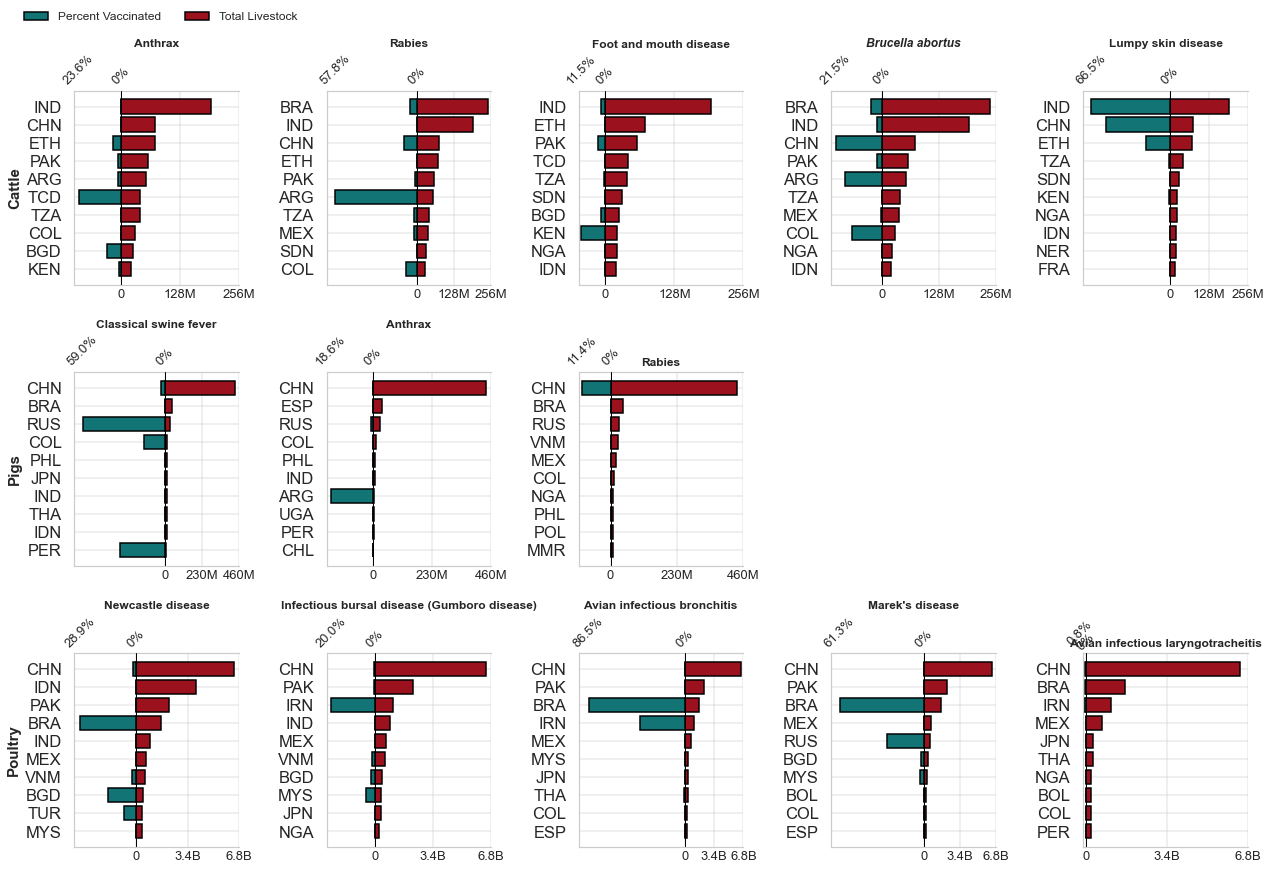

In [17]:
show_me = []
showme_2 = []

to_export_dfs=[]

total_color='#9B111E' # Imperial red
vacc_color = "#127475" # Deep cyan

def easier_format(num, pos):
    """
    Format large numbers into a more readable format.
    """
    if num >= 1_000_000_000:
        return f"{num/1_000_000_000:.1f}B"
    elif num >= 1_000_000:
        return f"{round(num/1_000_000)}M"
    elif num >= 1_000:
        return f"{round(num/1_000)}K"
    elif num >= 100:
        return f"{int(round(num, -2))}"
    else:
        return str(int(num))

def diverging_formatter_factory(s):
    def formatter(x, pos):
        if x < 0:
            return f"{abs(x)/s:.0f}%"
        else:
            return easier_format(x, pos)
    return formatter

df_2025 = df_calculations_vacc[df_calculations_vacc["Year"] == 2025].copy()

animal_groups = {"Cattle": [], "Pigs": [], "Poultry": []}
for disease in diseases_info:
    animal = disease["Animal"]
    if animal in animal_groups:
        animal_groups[animal].append(disease)
    else:
        animal_groups[animal] = [disease]

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.0)
plt.rcParams["axes.linewidth"] = 1.2

cols = 5  
rows = len(animal_groups)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4), sharex=False, sharey=False)
if rows == 1:
    axes = [axes]
else:
    axes = axes.reshape(rows, cols)
    
for row_idx, (animal, diseases) in enumerate(animal_groups.items()):
    group_max_total = df_2025[df_2025["Animal"] == animal]["latest pop"].max()
    group_common_xlim_right = group_max_total * 1.05
    group_xticks = np.linspace(0, group_common_xlim_right, 3)
    group_xtick_labels = [easier_format(x, None) for x in group_xticks]

    if not diseases:
        for c in range(cols):
            axes[row_idx, c].set_visible(False)
        continue

    for col_idx in range(cols):
        if col_idx < len(diseases):
            disease_info = diseases[col_idx]
            disease_name = disease_info["Disease"]
            ax = axes[row_idx, col_idx]

            if 'castle' not in disease_name:
                df_disease = df_2025[
                    (df_2025["Disease"] == disease_name) & 
                    (df_2025["Animal"] == animal) & 
                    (df_2025['Estimated (Scaled) Cases'].notna()) &
                    (~df_2025['Source_x'].str.contains('imputed', case=False, na=False))
                ]
            else:
                df_disease = df_2025[
                    (df_2025["Disease"] == disease_name) & 
                    (df_2025["Animal"] == animal) & 
                    (~df_2025['Source_x'].str.contains('imputed', case=False, na=False))
                ]
                
            df_disease=df_disease[(df_disease['Status in livestock']=='Present')]

                
            df_disease["Unvaccinated"] = df_disease["latest pop"] - df_disease["Number of Vaccinated Estimate"]

            top_countries = df_disease.nlargest(10, "Unvaccinated").copy()
            if top_countries.empty:
                ax.set_visible(False)
                continue

            max_total = top_countries['latest pop'].max()
            scale_factor = 10 * (max_total * 0.2 / 100)
            common_xlim_right = group_common_xlim_right  
            show_me += [top_countries]

            top_countries["vacc_percent"] = (
                top_countries["Number of Vaccinated Estimate"] / top_countries["latest pop"] * 100
            )
            to_export_dfs.append(top_countries)
            top_countries.sort_values("latest pop", ascending=False, inplace=True)

            local_max = top_countries["vacc_percent"].max()
            showme_2 += [local_max]

            # Label the leftmost subplot in each row with the animal name.
            if col_idx == 0:
                ax.set_ylabel(animal, fontsize=15, fontweight='bold')
            else:
                ax.set_ylabel("")
            display_max = local_max

            local_xlim_left = - (local_max * scale_factor * 1.05)

            ax.set_xlim(local_xlim_left * 1.05, common_xlim_right)

            ax.set_xticks(group_xticks)
            ax.set_xticklabels(group_xtick_labels, fontsize=13)  # increased font size for tick labels
            ax.xaxis.set_major_formatter(mtick.FuncFormatter(diverging_formatter_factory(scale_factor)))
            ax.tick_params(axis='x', which='major', length=0, width=0, direction='in', rotation=0, labelsize=13)

            # SECONDARY X-AXIS (top): Vaccinated (%).
            # These ticks reflect the blue bars (vaccinated %) on the negative side.
            secax = ax.secondary_xaxis('top')
            secax.set_xlim(-1 * (-local_xlim_left) * 1.05, 0)
            
            if local_max > 1.1:
                secax.set_xticks([-1 * (local_max * scale_factor), 0])            
                secax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
                secax.set_xticklabels([f"{local_max:.1f}%", f"{0}%"], fontsize=13)
            else:
                tick_pos = -1 * (local_max * scale_factor)
                secax.set_xticks([tick_pos, 0])
                secax.set_xticklabels(["", ""])
                ax.text(tick_pos * 2.5, 1.025, f"{local_max:.1f}%", 
                        ha='center', va='bottom', fontsize=13, rotation=45,
                        transform=ax.get_xaxis_transform())
                ax.text(0, 1.0, f"{0}%", 
                        ha='center', va='bottom', fontsize=13, rotation=45,
                        transform=ax.get_xaxis_transform())

            secax.tick_params(axis='x', rotation=45, length=0, width=0, labelsize=13)

            ax.axvline(0, color="black", linewidth=1)
            ax.invert_yaxis()
            
            if disease_name == "Brucella abortus (Inf. with)":
                ax.set_title("Brucella abortus", fontsize=12, fontweight="bold", fontstyle="italic")
            else:
                title_text = disease_name.replace(' (Inf. with)', '').replace(' (-2011)', '').replace(' virus','')
                if title_text.strip().lower() == "rabies" and animal.lower() == "pigs":
                    ax.set_title(title_text, fontsize=12, fontweight='bold',y=1)
                else:
                    ax.set_title(title_text, fontsize=12, fontweight='bold')
                

            ax.barh(top_countries["ISO3"], top_countries["latest pop"],
                    color=total_color, edgecolor="black", label="Total Livestock")
            ax.barh(top_countries["ISO3"], - top_countries["vacc_percent"] * scale_factor,
                    color=vacc_color, edgecolor="black", label="Percent Vaccinated")
        else:
            axes[row_idx, col_idx].set_visible(False)

handles, labels = [], []
for row in axes:
    for ax in row:
        if ax.get_visible():
            handles, labels = ax.get_legend_handles_labels()
            if handles and labels:
                break
    if handles and labels:
        break

handles, labels = handles[::-1], labels[::-1]

fig.legend(handles, labels, ncol=2, loc="upper left", bbox_to_anchor=(0.02, 1.02),
           frameon=False, fontsize=12)

sns.despine(fig=fig, left=False, bottom=False)
plt.tight_layout()

fig.savefig("vaccination_potential_back_to_back_bars.svg", format="svg", dpi=600, bbox_inches="tight")
fig.savefig("vaccination_potential_back_to_back_bars.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
def fmt_big(n):
    if pd.isna(n): return ""
    n = float(n)
    if n >= 1_000_000_000: return f"{n/1_000_000_000:.1f}B"
    if n >= 1_000_000:     return f"{n/1_000_000:.0f}M"
    if n >= 1_000:         return f"{n/1_000:.0f}K"
    return str(int(n))

def clean_title(name):
    t = name.replace(' (Inf. with)', '').replace(' (-2011)', '').replace(' virus','')
    if t == "Brucella abortus":  # optional italic look via fontstyle
        return t, True
    return t, False

def build_groups(diseases_info):
    groups = {"Cattle": [], "Pigs": [], "Poultry": []}
    for d in diseases_info:
        groups.setdefault(d["Animal"], []).append(d)
    return groups

def top10_unvax_slice(df, animal, disease):
    d = df[(df["Animal"]==animal) & (df["Disease"]==disease)].copy()
    if d.empty: 
        return d
    d["vaccinated"]   = d["Number of Vaccinated Estimate"].clip(lower=0)
    d["total"]        = d["latest pop"].clip(lower=0)
    d["unvaccinated"] = (d["total"] - d["vaccinated"]).clip(lower=0)
    d["vacc_percent"] = (100 * d["vaccinated"] / d["total"]).replace([np.inf, -np.inf], np.nan).fillna(0).clip(0,100)
    d = d.sort_values("unvaccinated", ascending=False).head(10)
    d = d.sort_values(["unvaccinated","total"], ascending=[True, True])
    return d


In [19]:
def build_groups(diseases_info):
    groups = {"Cattle": [], "Pigs": [], "Poultry": []}
    for d in diseases_info:
        animal = d["Animal"]
        groups.setdefault(animal, []).append(d)
    return groups
animal_groups = build_groups(diseases_info)

In [20]:
df_2025 = df_calculations_vacc[df_calculations_vacc["Year"] == 2025].copy()
df_2025 = df_2025[~(df_2025['Source_x'].str.contains('imputed'))].copy()

animal_groups = build_groups(diseases_info)

vacc_color = "#127475"  
gap_color  = "#c23b22"  
total_edge = "#333333"


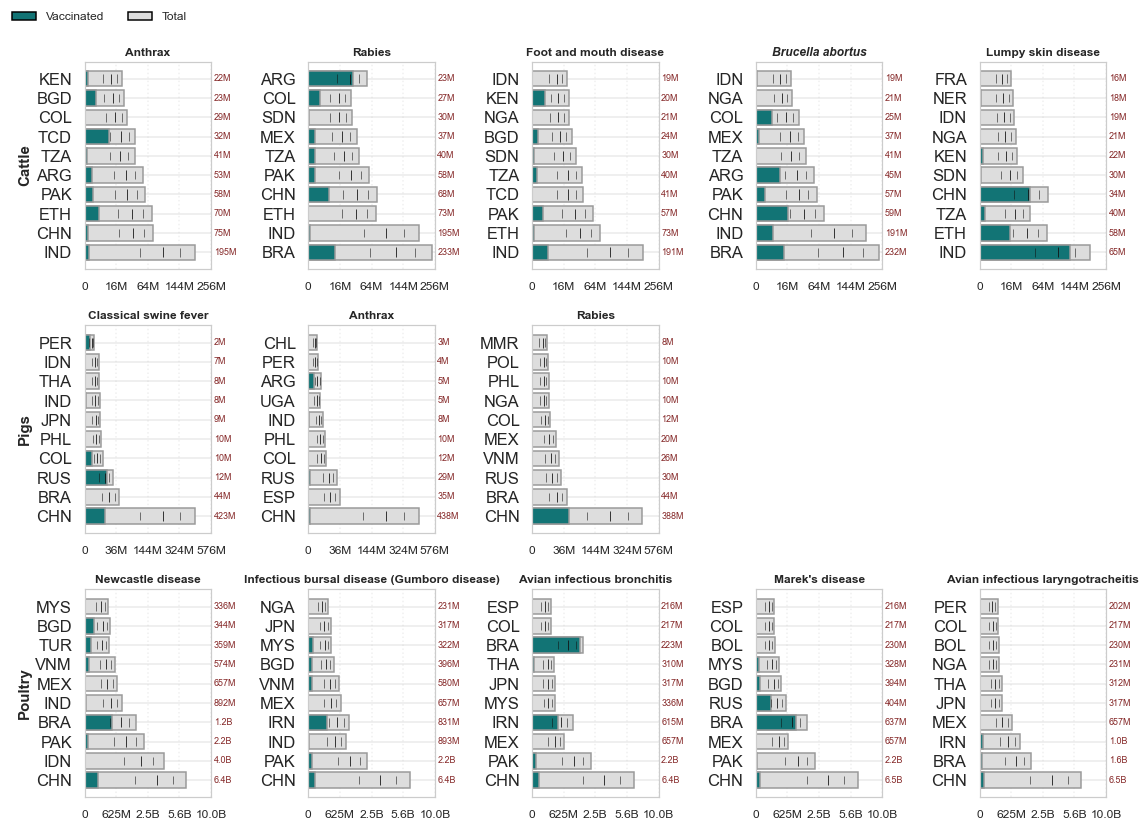

In [23]:
def sqrt_counts_with_total_ghost_notched(
        df_2025, animal_groups, cols=5,
        notch_color="#111111", notch_alpha=0.9,
        bar_height=0.8, notch_frac=0.55,
        notch_lw=1.2, mid_notch_scale=1.2,
        mid_notch_lw_scale=1.5,
        show_unvax_labels=True,
        unvax_label_fs=9,
        unvax_label_alpha=0.95,
        unvax_label_color="#7F1D1D",    
        unvax_label_offset_axes=0.02,   
        vacc_color="#127475",
        total_edge="#999999"
    ):
    """
    Vaccinated over ghost Total (√-scaled),  per-bar notches at
    25%, 50%, 75%. Tick labels show real counts (squared back).
    Unvaccinated counts shown as red text outside the right edge.

    """
    rows = len(animal_groups)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4*rows), squeeze=False)

    for r, (animal, diseases) in enumerate(animal_groups.items()):
        row_df = df_2025[df_2025["Animal"] == animal].copy()
        row_df["total"] = row_df["latest pop"].clip(lower=0)

        for c in range(cols):
            ax = axes[r, c]
            if c >= len(diseases):
                ax.set_visible(False)
                continue

            disease = diseases[c]["Disease"]
            

            d = top10_unvax_slice(df_2025[
    (df_2025['Status in livestock'].eq('Present')) &
    (~df_2025['Source_x'].str.contains('Imputed', case=False, na=False))
]
, animal, disease).copy()
            if d.empty:
                ax.set_visible(False)
                continue

            d["total"]        = d["total"].clip(lower=0)
            d["vaccinated"]   = d["vaccinated"].clip(lower=0)
            d["unvaccinated"] = (d["total"] - d["vaccinated"]).clip(lower=0)


            d = d.sort_values("unvaccinated", ascending=True)

            d["sqrt_total"] = np.sqrt(d["total"])
            d["sqrt_vacc"]  = np.sqrt(d["vaccinated"])
            d["sqrt_unvax"] = np.sqrt(d["unvaccinated"])

            y = np.arange(len(d))

            # bars
            ax.barh(y, d["sqrt_total"], color="#dddddd", edgecolor=total_edge,
                    height=bar_height, label="Total", zorder=1)
            ax.barh(y, d["sqrt_vacc"], color=vacc_color, edgecolor=total_edge,
                    height=bar_height, label="Vaccinated", zorder=2)

            # 25/50/75% notches on total (50% is taller & thicker)
            f_positions = [0.25, 0.5, 0.75]
            sqrt_multipliers = [np.sqrt(f) for f in f_positions]
            for i, st in enumerate(d["sqrt_total"].values):
                if st <= 0:
                    continue
                for f, m in zip(f_positions, sqrt_multipliers):
                    if f == 0.5:
                        half_notch = (bar_height * notch_frac * mid_notch_scale) / 2.0
                        lw_here = notch_lw * mid_notch_lw_scale * 0.5
                    else:
                        half_notch = (bar_height * notch_frac) / 2.0
                        lw_here = notch_lw * 0.5
                    y0, y1 = y[i] - half_notch, y[i] + half_notch
                    x_pos = m * st
                    ax.vlines(x_pos, y0, y1, colors=notch_color,
                              linewidth=lw_here, alpha=notch_alpha, zorder=3)

            if show_unvax_labels:
                trans = blended_transform_factory(ax.transAxes, ax.transData)
                x_anchors = 1.0 + unvax_label_offset_axes  
                for i, uv in enumerate(d["unvaccinated"].values):
                    if uv <= 0:
                        continue
                    ax.text(x_anchors, y[i], fmt_big(uv),
                            transform=trans, clip_on=False,
                            va='center', ha='left',
                            fontsize=unvax_label_fs, alpha=unvax_label_alpha,
                            color=unvax_label_color, zorder=5)

            ax.set_yticks(y)
            ax.set_yticklabels(d["ISO3"])
            ax.invert_yaxis()

            def _inv_square_fmt(x, pos):
                return fmt_big(x**2)
            ax.xaxis.set_major_formatter(mtick.FuncFormatter(_inv_square_fmt))

            local_max_total = float(d["total"].max()) if not d.empty else 0.0
            local_max_sqrt  = np.sqrt(local_max_total)

            loc_sqrt = MaxNLocator(nbins=4, min_n_ticks=3)
            ticks_sqrt = loc_sqrt.tick_values(0, local_max_sqrt)
            ticks_sqrt = ticks_sqrt[ticks_sqrt >= 0]

            # ensure 0 included
            if ticks_sqrt.size == 0 or ticks_sqrt[0] > 0:
                ticks_sqrt = np.insert(ticks_sqrt, 0, 0.0)

            if ticks_sqrt[-1] < local_max_sqrt:
                step_sqrt = ticks_sqrt[1] - ticks_sqrt[0] if ticks_sqrt.size > 1 else (local_max_sqrt if local_max_sqrt > 0 else 1.0)
                last_tick = np.ceil(local_max_sqrt / step_sqrt) * step_sqrt
                ticks_sqrt = np.append(ticks_sqrt, last_tick)
            else:
                idx = np.searchsorted(ticks_sqrt, local_max_sqrt, side="left")
                ticks_sqrt = ticks_sqrt[:idx+1]

            ax.set_xticks(ticks_sqrt)
            ax.set_xlim(0, ticks_sqrt[-1]) 
            ax.tick_params(axis='x', which='major', labelsize=12)  


            # titles/labels
            title, italic = clean_title(disease)
            ax.set_title(title, fontstyle='italic' if italic else 'normal',
                         fontsize=12, fontweight="bold")

            if c == 0:
                ax.set_ylabel(animal, fontsize=15, fontweight='bold')
            else:
                ax.set_ylabel("")

            ax.grid(axis='x', linestyle=':', alpha=0.3)

    legend_handles = [
        Patch(facecolor=vacc_color, edgecolor='black', label='Vaccinated'),
        Patch(facecolor='#dddddd', edgecolor='black', label='Total')
    ]
    fig.legend(legend_handles, [h.get_label() for h in legend_handles],
               ncol=2, loc="upper left", bbox_to_anchor=(0.0325, 1),
               frameon=False, fontsize=12)

    # extra right margin for outside labels
    fig.tight_layout(rect=[0.03, 0.03, 0.92, 0.97])
    fig.savefig("FINAL_FIG_2_design2_sqrt_counts_with_total_notches.png", dpi=600, bbox_inches="tight",facecolor="white",  transparent=False       # optional, but keeps it opaque
)
    plt.show()
sqrt_counts_with_total_ghost_notched(df_2025, animal_groups, cols=5)


In [25]:
Counter(pigs_most_countries).most_common()

[('China', 3),
 ('Russian Federation', 3),
 ('Colombia', 3),
 ('Philippines', 3),
 ('Brazil', 2),
 ('India', 2),
 ('Peru', 2),
 ('Japan', 1),
 ('Thailand', 1),
 ('Indonesia', 1),
 ('Spain', 1),
 ('Argentina', 1),
 ('Uganda', 1),
 ('Chile', 1),
 ('Viet Nam', 1),
 ('Mexico', 1),
 ('Nigeria', 1),
 ('Poland', 1),
 ('Myanmar', 1)]

In [26]:
Counter(cattle_most_countries).most_common()

[('India', 5),
 ('Tanzania, United Republic of', 5),
 ('China', 4),
 ('Ethiopia', 4),
 ('Pakistan', 4),
 ('Argentina', 3),
 ('Colombia', 3),
 ('Kenya', 3),
 ('Sudan', 3),
 ('Nigeria', 3),
 ('Indonesia', 3),
 ('Chad', 2),
 ('Bangladesh', 2),
 ('Brazil', 2),
 ('Mexico', 2),
 ('Niger', 1),
 ('France', 1)]

In [27]:
Counter(poultry_most_countries).most_common()

[('China', 5),
 ('Mexico', 5),
 ('Pakistan', 4),
 ('Brazil', 4),
 ('Malaysia', 4),
 ('Bangladesh', 3),
 ('Iran, Islamic Republic of', 3),
 ('Japan', 3),
 ('Colombia', 3),
 ('India', 2),
 ('Viet Nam', 2),
 ('Nigeria', 2),
 ('Thailand', 2),
 ('Spain', 2),
 ('Bolivia, Plurinational State of', 2),
 ('Indonesia', 1),
 ('Türkiye, Republic of', 1),
 ('Russian Federation', 1),
 ('Peru', 1)]

In [28]:
animal_groups

simplified_animal_diseases=dict()

for animal in animal_groups.keys():
    simplified_animal_diseases[animal]=[i['Disease'] for i in animal_groups[animal]]

In [29]:
simplified_animal_diseases={
 'Cattle': ['Anthrax',
  'Rabies virus (Inf. with)',
  'Foot and mouth disease virus (Inf. with)',
  'Brucella abortus (Inf. with)',
  'Lumpy skin disease virus (Inf. with)'],
 'Pigs': ['Classical swine fever virus (Inf. with)',
  'Anthrax',
  'Rabies virus (Inf. with)'],
 'Poultry': ['Newcastle disease',
  'Infectious bursal disease (Gumboro disease)',
  'Avian infectious bronchitis',
  "Marek's disease (-2011)",
  'Avian infectious laryngotracheitis'],}


In [30]:
top_3_disease={'Cattle': ['Lumpy skin disease virus (Inf. with)',
  'Echinococcosis/hydatidosis',
  'Foot and mouth disease virus (Inf. with)'],
 'Poultry': ['Newcastle disease (velogenic)',
  'Avian infectious bronchitis',
  'Low pathogenic avian influenza (poultry) (2006-2021)'],
 'Pigs': ['African swine fever virus (Inf. with)',
  'Echinococcosis/hydatidosis',
  'Porcine reproductive and respiratory syndrome virus (Inf. with)']}

Cattle : Anthrax
Cattle : Rabies virus (Inf. with)
Cattle : Foot and mouth disease virus (Inf. with)
Cattle : Brucella abortus (Inf. with)
Cattle : Lumpy skin disease virus (Inf. with)
Pigs : Classical swine fever virus (Inf. with)
Pigs : Anthrax
Pigs : Rabies virus (Inf. with)
Poultry : Newcastle disease
Poultry : Infectious bursal disease (Gumboro disease)
Poultry : Avian infectious bronchitis
Poultry : Marek's disease (-2011)
Poultry : Avian infectious laryngotracheitis


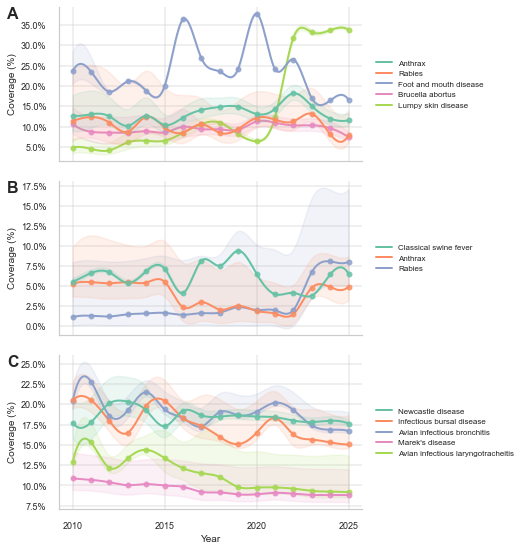

In [31]:
df_all = df_calculations_vacc.copy()
df_all["Unvaccinated"] = (df_all["latest pop"] - df_all["Number of Vaccinated Estimate"]).clip(lower=0)

colors = ['#66c2a5',  # teal
          '#fc8d62',  # coral
          '#8da0cb',  # light blue
          '#e78ac3',  # pale pink
          '#a6d854']  # light green

plt.rcParams["font.family"] = "Arial"
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=len(simplified_animal_diseases), ncols=1, figsize=(8, 8), sharex=True)
labels = ['A', 'B', 'C']  # Panel labels

for idx, (animal, diseases) in enumerate(simplified_animal_diseases.items()):
    ax = axes[idx]
    
    for i, disease in enumerate(diseases):
        print(f"{animal} : {disease}")
        
        # Filter data for the given disease and animal (ensure at-risk).
        if 'castle' not in disease:
            df_disease = df_all[
                (df_all["Disease"] == disease) &
                (df_all["Animal"] == animal) &
            (df_all['Status in livestock']=='Present')
            ]
        else:
            df_disease = df_all[
                (df_all["Disease"] == disease) &
                (df_all["Animal"] == animal) &
            (df_all['Status in livestock']=='Present')
            ]
        
        # Calculate coverage and confidence bounds (only for years ≥ 2010) (less samples, lower quality before 2010)
        coverage_per_year = {}
        coverage_per_year_lower = {}
        coverage_per_year_upper = {}
        for year in np.unique(df_disease['Year']):
            if year >= 2010:
                df_year = df_disease[df_disease['Year'] == year]
                total_pop = df_year['latest pop'].sum()
                if total_pop > 0:
                    coverage = df_year['Number of Vaccinated Estimate'].sum() / total_pop
                    coverage_lower = df_year['Number of Vaccinated Lower'].sum() / total_pop
                    coverage_upper = df_year['Number of Vaccinated Upper'].sum() / total_pop
                else:
                    coverage, coverage_lower, coverage_upper = np.nan, np.nan, np.nan
                coverage_per_year[year] = coverage
                coverage_per_year_lower[year] = coverage_lower
                coverage_per_year_upper[year] = coverage_upper
                
        years_sorted = np.array(sorted(coverage_per_year.keys()))
        coverage_vals = np.array([coverage_per_year[yr] for yr in years_sorted])
        lower_vals = np.array([coverage_per_year_lower[yr] for yr in years_sorted])
        upper_vals = np.array([coverage_per_year_upper[yr] for yr in years_sorted])
        
        # Smooth curves with interpolation
        interpolated_years = np.linspace(years_sorted.min(), years_sorted.max(), 500)
        try:
            spline = make_interp_spline(years_sorted, coverage_vals, k=3)
            smoothed_coverage = spline(interpolated_years)
            lower_spline = make_interp_spline(years_sorted, lower_vals, k=3)
            smoothed_lower = lower_spline(interpolated_years)
            upper_spline = make_interp_spline(years_sorted, upper_vals, k=3)
            smoothed_upper = upper_spline(interpolated_years)
        except Exception as e:
            interpolated_years = years_sorted
            smoothed_coverage = coverage_vals
            smoothed_lower = lower_vals
            smoothed_upper = upper_vals
        
        color = colors[i % len(colors)]
        zorder_conf = 10 - i
        zorder_line = 11 - i
        zorder_scatter = 12 - i
        
        # Plot the confidence interval as a semi-transparent filled area
        ax.fill_between(interpolated_years, smoothed_lower, smoothed_upper, color=color, alpha=0.12, zorder=zorder_conf)
        disease_label = (disease.replace(' (Inf. with)', '')
                                  .replace(' (Gumboro disease)', '')
                                  .replace(' virus', '')
                                  .replace(' (-2011)', ''))
        ax.plot(interpolated_years, smoothed_coverage, label=disease_label, color=color, linewidth=2, zorder=zorder_line)
        ax.scatter(years_sorted, coverage_vals, color=color, marker='o', alpha=0.8, s=20, zorder=zorder_scatter)
    
    ax.set_ylabel("Coverage (%)", fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='y', labelsize=9)
    
    min_year = int(years_sorted.min())
    max_year = int(years_sorted.max())
    tick_years = list(np.arange(min_year, max_year + 1, 5))
    if max_year not in tick_years:
        tick_years.append(max_year)
    tick_years = sorted(tick_years)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_years, fontsize=9, rotation=0)
    
    legend = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                       ncol=1, fontsize=8, frameon=True,
                       facecolor='white', edgecolor='none', framealpha=0.55)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(-0.17, 1, labels[idx], transform=ax.transAxes, fontsize=16, fontweight='bold',
            va='top', ha='left')

plt.xlabel("Year", fontsize=10)
plt.tight_layout()

fig.savefig('Estimated_Vaccination_Coverage_Over_Time_(Top_Targeted_Diseases).svg',
            format='svg', bbox_inches='tight', facecolor='white')
fig.savefig('Estimated_Vaccination_Coverage_Over_Time_(Top_Targeted_Diseases).png',
            format='png', bbox_inches='tight', dpi=600, facecolor='white')

plt.show()


Cattle : Lumpy skin disease virus (Inf. with)
Cattle : Echinococcosis/hydatidosis
Cattle : Foot and mouth disease virus (Inf. with)
Poultry : Newcastle disease (velogenic)
Poultry : Avian infectious bronchitis
Poultry : Low pathogenic avian influenza (poultry) (2006-2021)
Pigs : African swine fever virus (Inf. with)
Pigs : Echinococcosis/hydatidosis
Pigs : Porcine reproductive and respiratory syndrome virus (Inf. with)


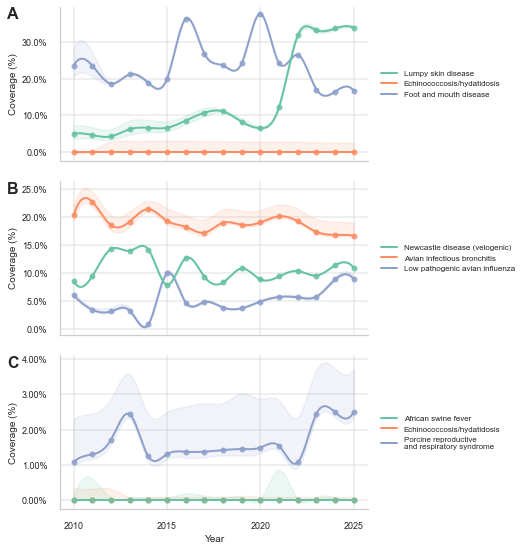

In [32]:
df_all = df_calculations_vacc.copy()
df_all["Unvaccinated"] = (df_all["latest pop"] - df_all["Number of Vaccinated Estimate"]).clip(lower=0)

colors = ['#66c2a5',  # teal
          '#fc8d62',  # coral
          '#8da0cb',  # light blue
          '#e78ac3',  # pale pink
          '#a6d854']  # light green

plt.rcParams["font.family"] = "Arial"
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=len(top_3_disease), ncols=1, figsize=(8, 8), sharex=True)
labels = ['A', 'B', 'C']  # Panel labels

for idx, (animal, diseases) in enumerate(top_3_disease.items()):
    ax = axes[idx]
    
    

    

    for i, disease in enumerate(diseases):
        print(f"{animal} : {disease}")
        
        
        # Filter data for the given disease and animal (ensure at-risk).
        df_disease = df_all[
            (df_all["Disease"] == disease) &
            (df_all["Animal"] == animal) &
            (df_all['Status in livestock']=='Present')
        ]
        
        # Calculate coverage and confidence bounds (only for years ≥ 2010) (less samples, lower quality before 2010)
        coverage_per_year = {}
        coverage_per_year_lower = {}
        coverage_per_year_upper = {}
        for year in np.unique(df_disease['Year']):
            if year >= 2010:
                df_year = df_disease[df_disease['Year'] == year]
                total_pop = df_year['latest pop'].sum()
                if total_pop > 0:
                    coverage = df_year['Number of Vaccinated Estimate'].sum() / total_pop
                    coverage_lower = df_year['Number of Vaccinated Lower'].sum() / total_pop
                    coverage_upper = df_year['Number of Vaccinated Upper'].sum() / total_pop
                else:
                    coverage, coverage_lower, coverage_upper = np.nan, np.nan, np.nan
                coverage_per_year[year] = coverage
                coverage_per_year_lower[year] = coverage_lower
                coverage_per_year_upper[year] = coverage_upper
        
        years_sorted = np.array(sorted(coverage_per_year.keys()))
        coverage_vals = np.array([coverage_per_year[yr] for yr in years_sorted])
        lower_vals = np.array([coverage_per_year_lower[yr] for yr in years_sorted])
        upper_vals = np.array([coverage_per_year_upper[yr] for yr in years_sorted])
        
        # Smooth curves with interpolation
        interpolated_years = np.linspace(years_sorted.min(), years_sorted.max(), 500)
        try:
            spline = make_interp_spline(years_sorted, coverage_vals, k=3)
            smoothed_coverage = spline(interpolated_years)
            lower_spline = make_interp_spline(years_sorted, lower_vals, k=3)
            smoothed_lower = lower_spline(interpolated_years)
            upper_spline = make_interp_spline(years_sorted, upper_vals, k=3)
            smoothed_upper = upper_spline(interpolated_years)
        except Exception as e:
            interpolated_years = years_sorted
            smoothed_coverage = coverage_vals
            smoothed_lower = lower_vals
            smoothed_upper = upper_vals
        
        color = colors[i % len(colors)]
        zorder_conf = 10 - i
        zorder_line = 11 - i
        zorder_scatter = 12 - i
        
        #Plot the confidence interval as a semi-transparent filled area
        ax.fill_between(interpolated_years, smoothed_lower, smoothed_upper, color=color, alpha=0.12, zorder=zorder_conf)
        #Plot the smoothed coverage line
        disease_label = disease.replace(' (Inf. with)','').replace(' (Gumboro disease)','').replace(' virus','').replace(' (-2011)','')
        disease_label=disease_label.replace(' (poultry) (2006-2021)','')
        if 'respiratory syndrome' in disease_label:
            disease_label= 'Porcine reproductive\nand respiratory syndrome'
        ax.plot(interpolated_years, smoothed_coverage, label=disease_label, color=color, linewidth=2, zorder=zorder_line)
        #Plot the original data points
        ax.scatter(years_sorted, coverage_vals, color=color, marker='o', alpha=0.8, zorder=zorder_scatter, s=20)
    
    ax.set_ylabel("Coverage (%)", fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='y', labelsize=9)
    
    min_year = int(years_sorted.min())
    max_year = int(years_sorted.max())
    tick_years = list(np.arange(min_year, max_year + 1, 5))
    if max_year not in tick_years:
        tick_years.append(max_year)
    tick_years = sorted(tick_years)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_years, fontsize=9, rotation=0)
    
    legend = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                       ncol=1, fontsize=8, frameon=True,
                       facecolor='white', edgecolor='none', framealpha=0.55)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(-0.17, 1, labels[idx], transform=ax.transAxes, fontsize=16, fontweight='bold',
            va='top', ha='left')

plt.xlabel("Year", fontsize=10)
plt.tight_layout()

fig.savefig('Estimated_Vaccination_Coverage_Over_Time_(Top_3_Reported_Diseases).svg',
            format='svg', bbox_inches='tight', facecolor='white')
fig.savefig('Estimated_Vaccination_Coverage_Over_Time_(Top_3_Reported_Diseases).png',
            format='png', bbox_inches='tight', dpi=600, facecolor='white')

plt.show()
